# Análise de Dados com Python - AT

https://deepnote.com/app/infnet-1d7e/Analise-com-Python-7e99ffde-dbe0-44b0-9d4a-4e77bb19de4e?utm_source=app-settings&utm_medium=product-shared-content&utm_campaign=data-app&utm_content=7e99ffde-dbe0-44b0-9d4a-4e77bb19de4e

## ETAPA 1 - Importação e exploração

<hr>

In [1]:
import pandas as pd

# Carregando o DataFrame a partir do conteúdo do texto
df = pd.read_csv("dataset_netflix.csv")

In [2]:
# Exibindo as primeiras linhas do DataFrame para inspeção
df.head()

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month


### 1.1 - Campos mais relevantes da base.

**User ID**: Identificador único de cada usuário. Essencial para rastrear e agregar dados por indivíduo.

**Subscription Type**: O tipo de plano assinado pelo usuário (Basic, Standard, Premium). Este campo é crucial para a análise de comportamento de consumo por plano.

**Monthly Revenue**: A receita gerada mensalmente por cada usuário.

**Join Date**: A data em que o usuário se juntou à plataforma. Fundamental para analisar a retenção de usuários e a evolução da base de clientes.

**Last Payment Date**: A data do último pagamento do usuário. Importante para entender a regularidade do pagamento e a saúde financeira da base.

**Country**: País de residência do usuário. Permite a análise de padrões de consumo por região geográfica.

**Age**: A idade do usuário. Este campo é chave para segmentar o público por faixa etária e personalizar o conteúdo e o marketing.

**Gender**: Gênero do usuário. Útil para entender as preferências de consumo entre gêneros.

**Device**: O dispositivo principal de acesso. Este campo é vital para a otimização da experiência do usuário em diferentes plataformas.

**Plan Duration**: A duração do plano de assinatura. Neste caso, o valor é sempre 

In [3]:
# Verificando se o DataFrame está vazio
print("O DataFrame está vazio?", df.empty)

# Exibindo as dimensões do DataFrame
print("\nDimensões do DataFrame (linhas, colunas):", df.shape)

# Exibindo os nomes das colunas e seus tipos de dados (dtypes)
print("\nInformações sobre o DataFrame:")
df.info()


O DataFrame está vazio? False

Dimensões do DataFrame (linhas, colunas): (2500, 10)

Informações sobre o DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   User ID            2500 non-null   int64 
 1   Subscription Type  2500 non-null   object
 2   Monthly Revenue    2500 non-null   int64 
 3   Join Date          2500 non-null   object
 4   Last Payment Date  2500 non-null   object
 5   Country            2500 non-null   object
 6   Age                2500 non-null   int64 
 7   Gender             2500 non-null   object
 8   Device             2500 non-null   object
 9   Plan Duration      2500 non-null   object
dtypes: int64(3), object(7)
memory usage: 195.4+ KB


<hr>

### 1.2 - Utilizando métodos métodos para explorar a estrutura da base.

Alguns métodos já foram utilizados nos blocos acima

In [4]:
# Exibindo as últimas linhas do DataFrame para inspeção
df.tail()

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
2495,2496,Premium,14,25-07-22,12-07-23,Spain,28,Female,Smart TV,1 Month
2496,2497,Basic,15,04-08-22,14-07-23,Spain,33,Female,Smart TV,1 Month
2497,2498,Standard,12,09-08-22,15-07-23,United States,38,Male,Laptop,1 Month
2498,2499,Standard,13,12-08-22,12-07-23,Canada,48,Female,Tablet,1 Month
2499,2500,Basic,15,13-08-22,12-07-23,United States,35,Female,Smart TV,1 Month


In [5]:
# Exibindo informações como contagem, média, desvio padrão, valor mínimo, 
# valor máximo e percentis para colunas numéricas

df.describe()

,User ID,Monthly Revenue,Age
count,2500.00000,2500.000000,2500.000000
mean,1250.50000,12.508400,38.795600
std,721.83216,1.686851,7.171778
min,1.00000,10.000000,26.000000
25%,625.75000,11.000000,32.000000
50%,1250.50000,12.000000,39.000000
75%,1875.25000,14.000000,45.000000
max,2500.00000,15.000000,51.000000


<hr>

### 2.1 - Principais pontos observados sobre os dados categóricos e numéricos.

 - Numéricos: distribuição bem delimitada (idade adulta jovem-média e receitas alinhadas aos planos).

 - Categóricos: concentração em alguns países, predominância feminina e maior uso de laptops. Algumas variáveis são fixas ou pouco variadas (ex: Plan Duration).

<hr>

### 2.2 - Usando count(), nunique()... para descrever as variáveis mais relevantes.

 - Os numéricos mostram valores bem concentrados e consistentes (receita e idade).

 - Os categóricos apresentam diversidade moderada (3 planos, 10 países, 4 dispositivos), mas ainda com concentração em algumas categorias principais.

## ETAPA 2 - Estruturação e persistência

<hr>

### 1.1 - Conversão de variáveis para o tipo apropriado (data ou categoria).

In [6]:
# --- Conversão de Tipos de Dados ---

# Converte as colunas 'Join Date' e 'Last Payment Date' para o formato datetime.
print("Convertendo colunas de data...")
df['Join Date'] = pd.to_datetime(df['Join Date'], format='%d-%m-%y', errors='coerce')
df['Last Payment Date'] = pd.to_datetime(df['Last Payment Date'], format='%d-%m-%y', errors='coerce')


# Converte colunas com um número limitado de valores únicos para o tipo 'category'.
print("Convertendo colunas para o tipo categoria...")
colunas_categoricas = ['Subscription Type', 'Country', 'Gender', 'Device', 'Plan Duration']
for coluna in colunas_categoricas:
    df[coluna] = df[coluna].astype('category')

# Exibe novamente as informações do DataFrame para confirmar que os tipos foram alterados com sucesso.
print("\n### Tipos de Dados Após a Conversão ###")
df.info()
print("\n" + "="*50 + "\n")

# Exibe as primeiras 5 linhas novamente para mostrar como os dados se parecem após as conversões.
print("### Amostra dos Dados Convertidos ###")
print(df.head())

Convertendo colunas de data...
Convertendo colunas para o tipo categoria...

### Tipos de Dados Após a Conversão ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   User ID            2500 non-null   int64         
 1   Subscription Type  2500 non-null   category      
 2   Monthly Revenue    2500 non-null   int64         
 3   Join Date          2500 non-null   datetime64[ns]
 4   Last Payment Date  2500 non-null   datetime64[ns]
 5   Country            2500 non-null   category      
 6   Age                2500 non-null   int64         
 7   Gender             2500 non-null   category      
 8   Device             2500 non-null   category      
 9   Plan Duration      2500 non-null   category      
dtypes: category(5), datetime64[ns](2), int64(3)
memory usage: 110.9 KB


### Amostra dos Dados Convertidos ###
   U

As conversões realizadas são passos fundamentais na preparação de dados para análise. Originalmente, as colunas Join Date e Last Payment Date são lidas como object no pandas. Nessa forma, o computador não as entende como datas, mas sim como uma simples sequência de caracteres. Isso impede qualquer operação temporal. Ao converter o pandas entende que esses valores são pontos no tempo, com isso podemos calcular durações, ordenar os dados cronologicamente, agrupar dados por periodos e etc... 

Já as columas como "Country" e "Gender" contém um número limitado de valores que se repetem. A conversão para o tipo "category" traz duas grandes vantagens: Eficiência de memória e melhora de performance.

### 1.2 - Colunas Úteis para Filtros em Dashboards

As colunas mais úteis seriam:

Country: Para analisar o desempenho da plataforma por região, comparar a receita ou o número de usuários em diferentes países.

Subscription Type: Esssencial para comparar o comportamento de usuários dos planos Basic, Standard e Premium.

Device: Para entender em quais dispositivos o serviço é mais utilizado, o que pode guiar decisões de desenvolvimento e marketing.

Gender: Permite uma análise demográfica básica do perfil dos usuários.

Join Date e Last Payment Date: Após a conversão, essas colunas se tornam filtros de tempo poderosos, permitindo que o usuário do dashboard selecione um período específico para analisar os dados.

Age: Embora seja numérica, em um dashboard é comum criar "faixas etárias" (ex: 18-25, 26-35, 36-50, etc.) para usar como um filtro categórico e analisar o comportamento de diferentes gerações.

### 2.1 - Filtre os dados para obter apenas usuários com último pagamento a pelo menos 6 meses.

In [94]:
# Remove linhas onde a conversão da data de pagamento falhou, garantindo a integridade dos dados para o filtro.
df.dropna(subset=['Last Payment Date'], inplace=True)


# --- Lógica do Filtro ---

# 1. Encontra a data mais recente de pagamento em todo o conjunto de dados.
data_mais_recente = df['Last Payment Date'].max()

# 2. Calcula a data de corte, que é 6 meses antes da data mais recente.
data_de_corte = data_mais_recente - pd.DateOffset(months=6) # Não há dados para exibir em 6 meses
#data_de_corte = data_mais_recente - pd.DateOffset(days=20) # 20 dias sim.

# 3. Aplica o filtro para obter apenas os usuários cuja data de último pagamento é anterior ou igual à data de corte.
df_filtrado = df[df['Last Payment Date'] <= data_de_corte]


# --- Exibição dos Resultados ---
print("--- Análise de Usuários com Pagamentos Antigos ---")
print(f"A data de pagamento mais recente no dataset é: {data_mais_recente.strftime('%d/%m/%Y')}")
print(f"A data de corte para o filtro (6 meses antes) é: {data_de_corte.strftime('%d/%m/%Y')}")
print("-" * 50)

# Exibe o número de usuários encontrados e uma amostra dos dados.
print(f"\nForam encontrados {len(df_filtrado)} usuários com último pagamento há pelo menos 6 meses.")
print("Amostra dos usuários filtrados:")
df_filtrado.head()



--- Análise de Usuários com Pagamentos Antigos ---
A data de pagamento mais recente no dataset é: 15/07/2023
A data de corte para o filtro (6 meses antes) é: 15/01/2023
--------------------------------------------------

Foram encontrados 0 usuários com último pagamento há pelo menos 6 meses.
Amostra dos usuários filtrados:


,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,Weekly Hours Watched,Engaged Hours,Faixa Etária


### 2.2 - Exportando o dataframe filtrado

In [8]:
# Exporto o conjunto de dados para um csv
df_filtrado.to_csv('df_filtrao.csv', sep=';')

### 3 - Modificando receita mensal

In [9]:
print("--- Modificando Receita Mensal ---")
print("Aumentando a receita em 10% para usuários de dispositivos móveis (Smartphone/Tablet)...")

# Cria uma máscara booleana para identificar as linhas onde o dispositivo é 'Smartphone' ou 'Tablet'.
mobile_mask = df['Device'].isin(['Smartphone', 'Tablet'])

# Usa .loc para selecionar as linhas e a coluna 'Monthly Revenue' e aplicar o aumento de 10%.
df.loc[mobile_mask, 'Monthly Revenue'] = df.loc[mobile_mask, 'Monthly Revenue'] * 1.10

print("Modificação concluída.")
print("-" * 50)

print("Amostra dos usuários com receita ajustada para usuários móveis:")
df.head()

--- Modificando Receita Mensal ---
Aumentando a receita em 10% para usuários de dispositivos móveis (Smartphone/Tablet)...
Modificação concluída.
--------------------------------------------------
Amostra dos usuários com receita ajustada para usuários móveis:
/tmp/ipykernel_150/320846948.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[11.  16.5 11.  ... 12.1 14.3 14.3]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mobile_mask, 'Monthly Revenue'] = df.loc[mobile_mask, 'Monthly Revenue'] * 1.10


,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,11.0,2022-01-15,2023-06-10,United States,28,Male,Smartphone,1 Month
1,2,Premium,16.5,2021-09-05,2023-06-22,Canada,35,Female,Tablet,1 Month
2,3,Standard,12.0,2023-02-28,2023-06-27,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12.0,2022-07-10,2023-06-26,Australia,51,Female,Laptop,1 Month
4,5,Basic,11.0,2023-05-01,2023-06-28,Germany,33,Male,Smartphone,1 Month


### 3.1 - Revertendo modificação da receita mensal

In [10]:
df.loc[mobile_mask, 'Monthly Revenue'] = df.loc[mobile_mask, 'Monthly Revenue'] / 1.10
df.head()


,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10.0,2022-01-15,2023-06-10,United States,28,Male,Smartphone,1 Month
1,2,Premium,15.0,2021-09-05,2023-06-22,Canada,35,Female,Tablet,1 Month
2,3,Standard,12.0,2023-02-28,2023-06-27,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12.0,2022-07-10,2023-06-26,Australia,51,Female,Laptop,1 Month
4,5,Basic,10.0,2023-05-01,2023-06-28,Germany,33,Male,Smartphone,1 Month


**A motivação é simular uma situação hipotética para medir seus efeitos. É uma forma de usar os dados para testar hipóteses ("O que aconteceria se...?") de forma segura e controlada.**

### 4 -  Índice hierárquico

In [11]:
print("--- Criando Índice Hierárquico ---")
# Define 'Country' e 'Subscription Type' como os níveis do índice.
df_multi_index = df.set_index(['Country', 'Subscription Type']).sort_index()

print("DataFrame com o novo índice hierárquico (País e Tipo de Assinatura):")
df_multi_index.head()

--- Criando Índice Hierárquico ---
DataFrame com o novo índice hierárquico (País e Tipo de Assinatura):


User ID  Monthly Revenue  Join Date  \
Country   Subscription Type                                        
Australia Basic                   14             10.0 2022-08-01   
          Basic                  164             11.0 2022-03-11   
          Basic                  314             10.0 2022-04-21   
          Basic                  464             13.0 2022-06-03   
          Basic                  539             12.0 2022-07-02   

                            Last Payment Date  Age  Gender      Device  \
Country   Subscription Type                                              
Australia Basic                    2023-06-26   27    Male  Smartphone   
          Basic                    2023-06-26   42  Female      Tablet   
          Basic                    2023-06-26   28    Male      Laptop   
          Basic                    2023-06-28   45    Male      Laptop   
          Basic                    2023-06-29   30  Female      Tablet   

                            Plan Duration  
Country   Subscription Type                
Australia Basic                   1 Month  
          Basic                   1 Month  
          Basic                   1 Month  
          Basic                   1 Month  
          Basic                   1 Month

In [12]:
print("\n--- Exemplo de Seleção ---")

# Seleciona todos os usuários do Canadá.
print("\nSelecionando todos os usuários do 'Canada':")
selecao_canada = df_multi_index.loc['Canada']
selecao_canada.head()


--- Exemplo de Seleção ---

Selecionando todos os usuários do 'Canada':


,User ID,Monthly Revenue,Join Date,Last Payment Date,Age,Gender,Device,Plan Duration
Subscription Type,,,,,,,,
Basic,22,10.0,2022-07-22,2023-06-28,34,Male,Smartphone,1 Month
Basic,32,10.0,2022-07-07,2023-06-28,37,Male,Tablet,1 Month
Basic,42,10.0,2022-06-15,2023-06-28,40,Male,Smartphone,1 Month
Basic,52,10.0,2022-08-29,2023-06-28,37,Male,Tablet,1 Month
Basic,62,10.0,2022-08-03,2023-06-28,37,Male,Smartphone,1 Month


A criação de um índice hierárquico é muito útil para agrupar e analisar dados de forma mais intuitiva, especialmente quando você tem categorias aninhadas, como tipos de assinatura dentro de cada país.

## ETAPA 3 - Visualização exploratória

### 1 - Histograma da variável de receita mensal usando Matplotlib


--- Gerando Histograma da Receita Mensal ---
Exibindo o histograma...


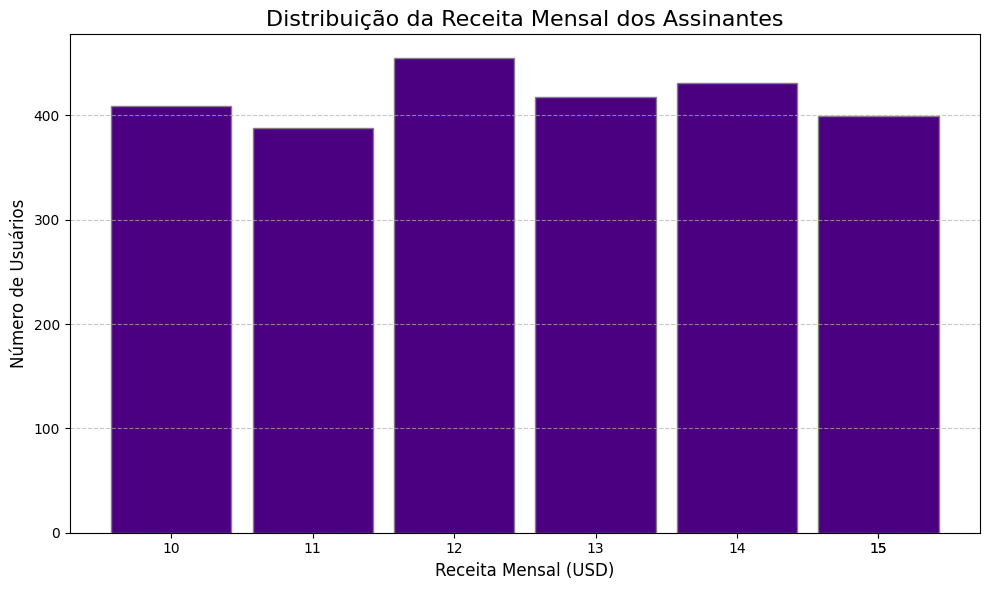

In [13]:
import matplotlib.pyplot as plt

print("\n--- Gerando Histograma da Receita Mensal ---")

# Define os limites dos bins para que cada barra represente um valor de receita único.
bins = [9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5]

# Define o tamanho da figura para melhor visualização.
plt.figure(figsize=(10, 6))

# Cria o histograma.
plt.hist(df['Monthly Revenue'], bins=bins, color='indigo', edgecolor='grey', rwidth=0.85)

# Personalizando o gráfico com título e rótulos dos eixos.
plt.title('Distribuição da Receita Mensal dos Assinantes', fontsize=16)
plt.xlabel('Receita Mensal (USD)', fontsize=12)
plt.ylabel('Número de Usuários', fontsize=12)

# Garante que os ticks do eixo X correspondam aos valores exatos da receita.
plt.xticks(sorted(df['Monthly Revenue'].unique()))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibe o gráfico.
print("Exibindo o histograma...")
plt.tight_layout()
plt.show()

Distribuição: A receita não é uma variável contínua; ela se concentra em valores inteiros específicos (10, 11, 12, 13, 14, 15). Isso acontece porque cada valor corresponde ao preço de um plano de assinatura específico. 

Múltiplos Picos (Distribuição Multimodal): O gráfico provavelmente apresenta vários picos de frequência. Cada pico representa o preço de um dos planos principais. Por exemplo, podemos esperar picos nos valores correspondentes aos planos "Basic", "Standard" e "Premium", que são os mais populares.

Concentração de Assinantes: A altura das barras indica quais faixas de preço e, consequentemente, quais planos são as mais comuns. Observando o gráfico, é possível identificar rapidamente qual plano de assinatura gera a maior base de usuários. 

### 2 - Boxplot da variável idade segmentada por tipo de assinatura


--- Gerando Boxplot de Idade por Tipo de Assinatura ---
Exibindo o boxplot...
/tmp/ipykernel_150/2908418831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Subscription Type', y='Age', data=df, palette='viridis')


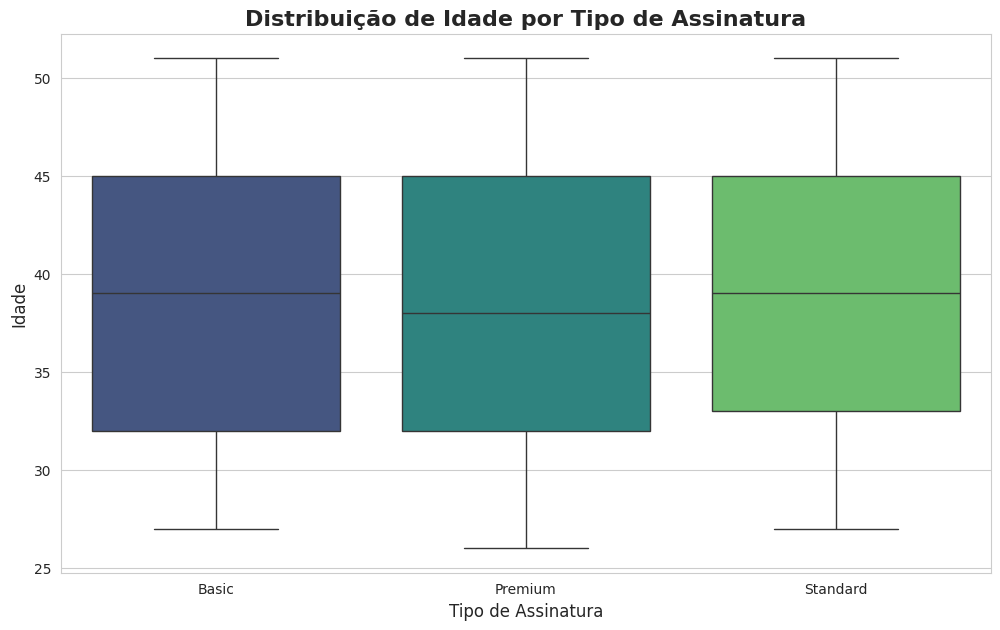

In [14]:
import seaborn as sns

print("\n--- Gerando Boxplot de Idade por Tipo de Assinatura ---")

# Define um estilo estético para o gráfico.
sns.set_style("whitegrid")

# Define o tamanho da figura para melhor visualização.
plt.figure(figsize=(12, 7))

# Cria o boxplot.
sns.boxplot(x='Subscription Type', y='Age', data=df, palette='viridis')

# Personalizando o gráfico com título e rótulos dos eixos.
plt.title('Distribuição de Idade por Tipo de Assinatura', fontsize=16, fontweight='bold')
plt.xlabel('Tipo de Assinatura', fontsize=12)
plt.ylabel('Idade', fontsize=12)

# Melhora a legibilidade dos rótulos do eixo x, se necessário.
plt.xticks(rotation=0)

# Exibe o gráfico.
print("Exibindo o boxplot...")
plt.show()

As caixas (que representam o intervalo interquartil, ou seja, os 50% centrais dos usuários) têm tamanhos muito parecidos. Os "bigodes" também se estendem por uma faixa de idade similar.

A variabilidade da idade dentro de cada grupo de assinatura é muito baixa e homogênea

A principal conclusão tirada deste gráfico é a  semelhança no perfil etário entre os diferentes tipos de assinatura. Com base nestes dados, a idade não parece ser um fator determinante na escolha entre os planos Basic, Standard ou Premium. Todos os planos atraem uma faixa etária muito similar, tanto em termos de média quanto de dispersão.

### 3 - Grade (subplot) com 3 visualizações:

/tmp/ipykernel_150/331450411.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.index, y=country_counts.values, ax=ax1, palette='mako')
/tmp/ipykernel_150/331450411.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Age', y='Monthly Revenue', data=df, ax=ax2, jitter=0.2, alpha=0.6, size=4, palette='rocket')
Exibindo o dashboard com as três visualizações...


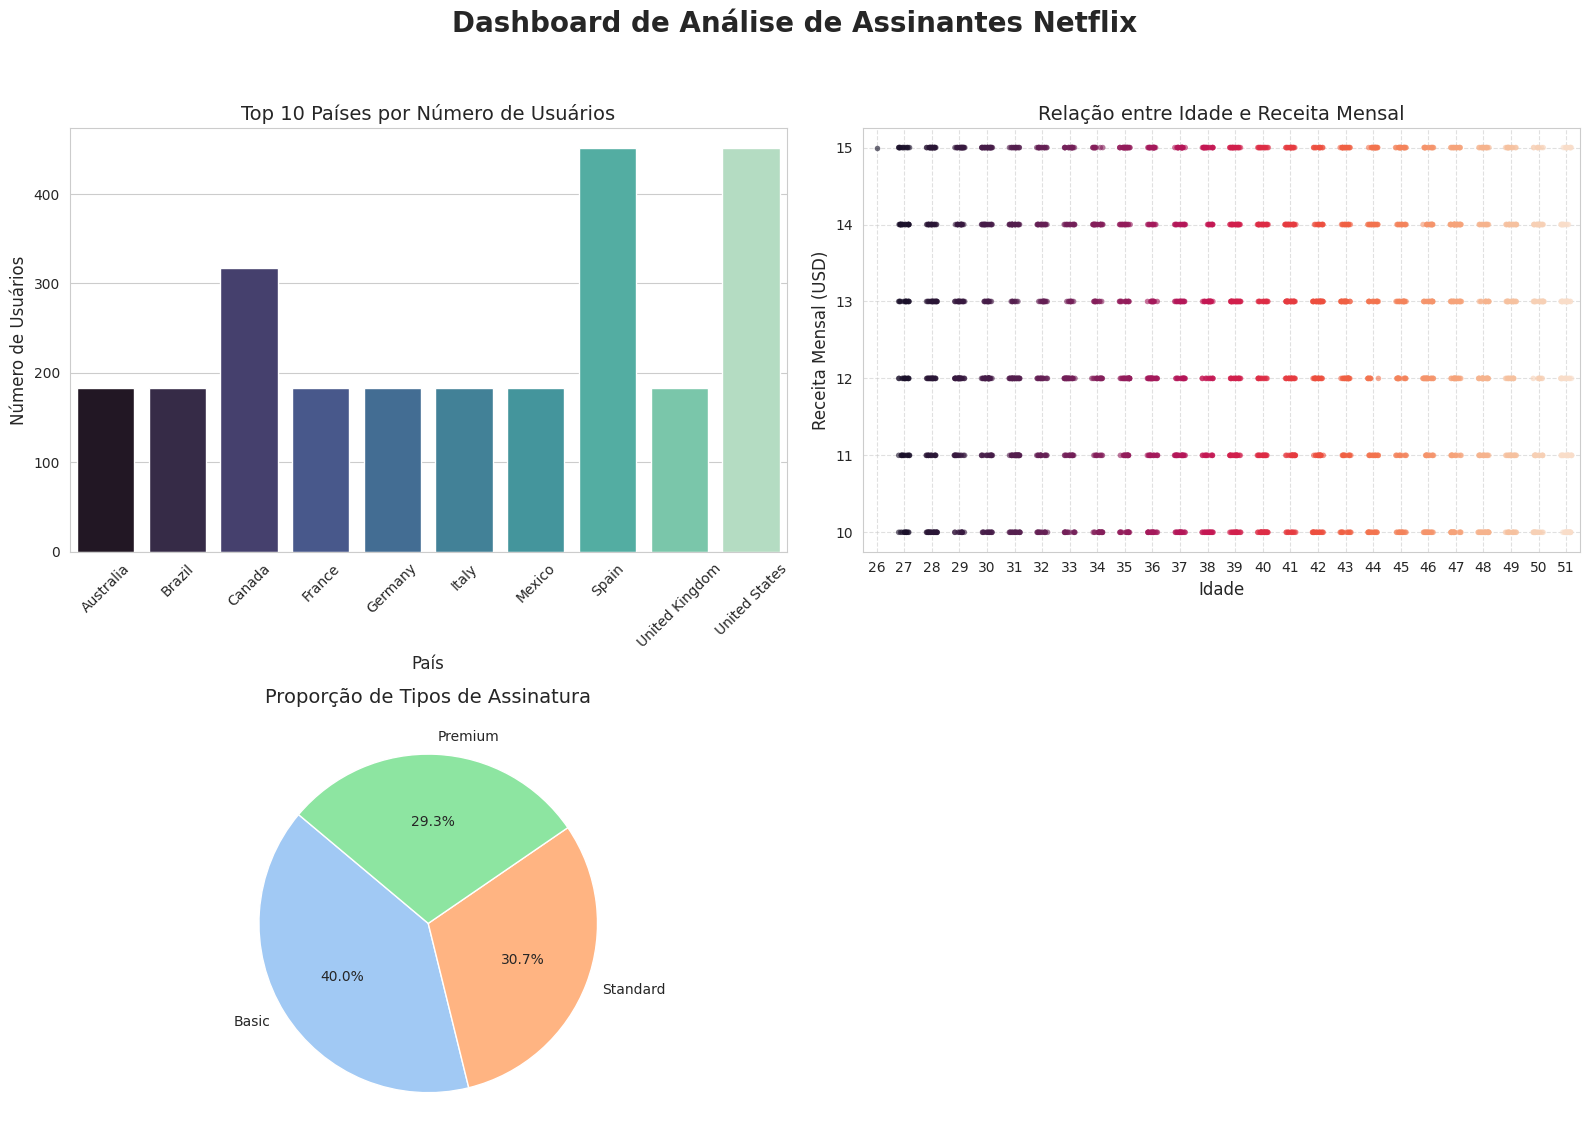

In [15]:
# --- Configuração da Grade (Subplot) ---
# Cria uma figura e uma grade de eixos 2x2 para acomodar os gráficos.
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
# Adiciona um título geral para toda a figura.
fig.suptitle('Dashboard de Análise de Assinantes Netflix', fontsize=20, fontweight='bold')


# --- 1. Gráfico de Barras: Contagem de Usuários por País ---
ax1 = axes[0, 0]
# Conta os usuários por país e seleciona os 10 principais para clareza.
country_counts = df['Country'].value_counts().nlargest(10)
sns.barplot(x=country_counts.index, y=country_counts.values, ax=ax1, palette='mako')
ax1.set_title('Top 10 Países por Número de Usuários', fontsize=14)
ax1.set_xlabel('País', fontsize=12)
ax1.set_ylabel('Número de Usuários', fontsize=12)
ax1.tick_params(axis='x', rotation=45) # Rotaciona os rótulos dos países para melhor leitura


# --- 2. Gráfico de Dispersão: Idade vs. Receita Mensal ---
ax2 = axes[0, 1]
sns.stripplot(x='Age', y='Monthly Revenue', data=df, ax=ax2, jitter=0.2, alpha=0.6, size=4, palette='rocket')
ax2.set_title('Relação entre Idade e Receita Mensal', fontsize=14)
ax2.set_xlabel('Idade', fontsize=12)
ax2.set_ylabel('Receita Mensal (USD)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)


# --- 3. Gráfico de Pizza: Proporção de Tipos de Assinatura ---
ax3 = axes[1, 0]
subscription_counts = df['Subscription Type'].value_counts()
# Define cores para o gráfico de pizza
colors = sns.color_palette('pastel')[0:len(subscription_counts)]
ax3.pie(subscription_counts, labels=subscription_counts.index, autopct='%1.1f%%', startangle=140, colors=colors,
        wedgeprops={"edgecolor": "white", 'linewidth': 1})
ax3.set_title('Proporção de Tipos de Assinatura', fontsize=14)


# --- Limpeza da Grade ---
# Remove o eixo não utilizado (canto inferior direito)
fig.delaxes(axes[1, 1])


# --- Finalização ---
# Ajusta o layout para evitar que os títulos e eixos se sobreponham.
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta para o super-título caber

# Exibe o dashboard.
print("Exibindo o dashboard com as três visualizações...")
plt.show()


GRÁFICO DE DISPERSÃO

o gráfico de dispersão comunica a ausência de uma correlação ou relação aparente entre a idade do usuário e a receita mensal que ele gera. Existe uma distribuição uniforme, visualmente, para cada linha horizontal de receita (10, 12, 15, etc.), os pontos que representam as idades dos usuários estão espalhados por toda a faixa etária, da esquerda para a direita. Não há uma concentração de pontos em idades mais jovens ou mais velhas para nenhum plano de assinatura específico. O gráfico nos mostra que a idade não parece ser um fator decisivo para que um cliente escolha um plano mais barato ou mais caro. Usuários de todas as idades estão distribuídos de forma muito semelhante entre os diferentes níveis de preço.

## ETAPA 4 - Agrupamentos e agregações

### 1 - Dados agrupados por país e tipo de assinatura

In [22]:
# --- Agrupamento e Cálculo de Métricas ---

# Agrupa o DataFrame por 'Country' e 'Subscription Type'.
# Em seguida, calcula a média ('mean') e a mediana ('median') da 'Monthly Revenue' para cada grupo.
aggregated_data = df.groupby(['Country', 'Subscription Type'])['Monthly Revenue'].agg(['mean', 'median'])

# Renomeia as colunas para maior clareza em português.
aggregated_data.rename(columns={'mean': 'Receita Média', 'median': 'Receita Mediana'}, inplace=True)

# --- Exibição dos Resultados ---

print("--- Receita Média e Mediana por País e Tipo de Assinatura ---")
# Imprime a tabela com os resultados da agregação.
# A função pd.set_option é usada para garantir que todas as linhas sejam exibidas.
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(aggregated_data)

--- Receita Média e Mediana por País e Tipo de Assinatura ---
                                  Receita Média  Receita Mediana
Country        Subscription Type                                
Australia      Basic                  12.193548             12.0
               Premium                12.415842             12.0
               Standard               12.529412             12.0
Brazil         Basic                  12.493151             13.0
               Premium                12.424242             12.0
               Standard               12.750000             13.0
Canada         Basic                  12.524138             12.0
               Premium                12.340909             12.0
               Standard               12.476190             12.0
France         Basic                  12.361111             12.0
               Premium                12.666667             13.0
               Standard                     NaN              NaN
Germany        Basic        

As principais diferenças observadas nos agrupamentos são que existe uma consistência dentro do mesmo tipo de assinatura,
por exemplo para assinatura "Basic", a Receita Média e a Receita Mediana são praticamente idênticas em todos os países.  Isso ocorre porque o preço de cada plano de assinatura é fixo. Um usuário do plano "Premium" paga o valor "Premium", independentemente de estar no Brasil ou na Alemanha. Como não há variação de preço dentro de cada categoria de plano, a média e a mediana para esse grupo serão sempre o valor do próprio plano.

## 2 - Faixas etárias (<18, 18–30, 31–45, 46–60, 60+)

In [46]:
import numpy as np

# --- 1. Criação de Dados Simulados ---
# O dataset não possui horas assistidas. 
np.random.seed(42)
df['Weekly Hours Watched'] = np.random.uniform(5, 25, size=len(df)).round(2)

# --- 2. Função Personalizada com @np.vectorize ---
# Esta função simula um bônus de engajamento para a faixa etária mais jovem.
# O decorador @np.vectorize permite que a função, que opera em um único valor,
# seja aplicada a um array inteiro do NumPy (como uma coluna do Pandas) de forma eficiente.
@np.vectorize
def aplicar_bonus_engajamento(idade, horas):
    """Aplica um bônus de 20% nas horas assistidas para usuários até 30 anos."""
    if idade <= 30:
        return horas * 1.20
    else:
        return horas

# Aplicando a função vetorizada para criar uma nova coluna
df['Engaged Hours'] = aplicar_bonus_engajamento(df['Age'], df['Weekly Hours Watched']).round(2)


# --- 3. Criação das Faixas Etárias ---
# Define os limites (bins) e os rótulos para cada faixa etária.
bins = [0, 17, 30, 45, 60, np.inf]
labels = ['< 18', '18–30', '31–45', '46–60', '60+']

# Cria a nova coluna 'Faixa Etária' usando a função pd.cut
df['Faixa Etária'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)


# --- 4. Agrupamento e Cálculo ---
# Agrupa os dados pela nova coluna 'Faixa Etária'
# e calcula a média das horas com bônus ('Engaged Hours') e da receita ('Monthly Revenue').
analise_por_faixa = df.groupby('Faixa Etária')[['Engaged Hours', 'Monthly Revenue']].mean().round(2)

# Renomeia as colunas para maior clareza
analise_por_faixa.rename(columns={
    'Engaged Hours': 'Média de Horas (com Bônus)',
    'Monthly Revenue': 'Média de Receita Mensal'
}, inplace=True)


# --- 5. Exibição dos Resultados ---
print("--- Análise de Métricas por Faixa Etária ---")
analise_por_faixa.head()

--- Análise de Métricas por Faixa Etária ---
/tmp/ipykernel_150/536430472.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analise_por_faixa = df.groupby('Faixa Etária')[['Engaged Hours', 'Monthly Revenue']].mean().round(2)


,Média de Horas (com Bônus),Média de Receita Mensal
Faixa Etária,,
< 18,NaN,NaN
18–30,17.81,12.64
31–45,15.09,12.50
46–60,14.78,12.43
60+,NaN,NaN


O grupo 18–30 é o que consome mais, apresentando a maior Média de Horas Assistidas, mas não há uma diferença relevante na média de receita mensal entre as faixas etárias. Os valores são muito similares para todos os grupos.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=7e99ffde-dbe0-44b0-9d4a-4e77bb19de4e' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>